In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_mlp_pollution.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.420798
2014-07-04 22:00:00,0.559069,0.555358
2014-07-04 23:00:00,0.613930,0.599092
2014-07-05 00:00:00,0.745596,0.726853
2014-07-05 01:00:00,0.789484,0.605953


In [7]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_lstm_pollution.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.264178
2014-07-04 22:00:00,0.559069,0.395738
2014-07-04 23:00:00,0.613930,0.474377
2014-07-05 00:00:00,0.745596,0.483577
2014-07-05 01:00:00,0.789484,0.412241


In [8]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/24pasos_gru_pollution.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 10
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.334962
2014-07-04 22:00:00,0.559069,0.437290
2014-07-04 23:00:00,0.613930,0.478565
2014-07-05 00:00:00,0.745596,0.508283
2014-07-05 01:00:00,0.789484,0.455417


In [9]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/crossformerPollution.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.200241
2014-07-04 22:00:00,0.559069,0.291358
2014-07-04 23:00:00,0.613930,0.293672
2014-07-05 00:00:00,0.745596,0.329007
2014-07-05 01:00:00,0.789484,0.261832


In [10]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/itransformerPollution.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.434569
2014-07-04 22:00:00,0.559069,0.794278
2014-07-04 23:00:00,0.613930,0.798075
2014-07-05 00:00:00,0.745596,0.968433
2014-07-05 01:00:00,0.789484,0.966470


In [11]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARX/24paso/pollution/tftPollution.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 4468 - 4337 - 21
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2014-07-04 21:00:00,0.789484,0.161209
2014-07-04 22:00:00,0.559069,0.230772
2014-07-04 23:00:00,0.613930,0.283441
2014-07-05 00:00:00,0.745596,0.332517
2014-07-05 01:00:00,0.789484,0.273267


## MLP ##

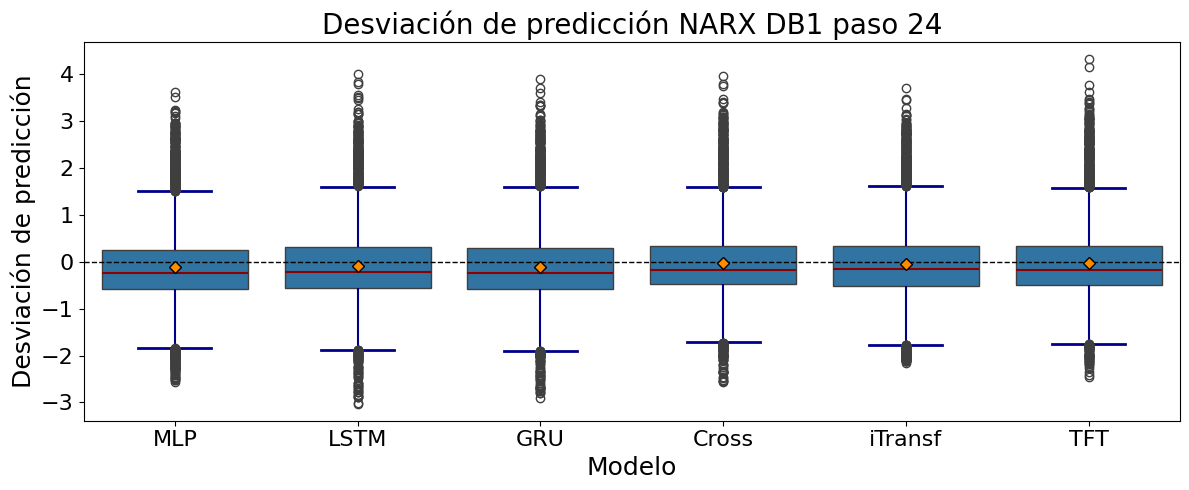

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARX DB1 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda


plt.tight_layout()
plt.show()


# Graficos Q-Q

In [13]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-07-04 21:00:00,0.368686,0.525306,0.454523,0.589244,0.354916,0.628276
2014-07-04 22:00:00,0.003711,0.163331,0.121779,0.267711,-0.235209,0.328297
2014-07-04 23:00:00,0.014838,0.139552,0.135364,0.320258,-0.184146,0.330489
2014-07-05 00:00:00,0.018743,0.262019,0.237313,0.416589,-0.222837,0.413079
2014-07-05 01:00:00,0.183532,0.377243,0.334067,0.527653,-0.176985,0.516217


In [14]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [15]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2014-08-18 14:00:00,0.141433,0.142819,0.097013,0.179940,0.112827,0.090960
2014-08-09 13:00:00,-0.100825,-0.171768,-0.252174,-0.131031,-0.261884,-0.306037
2014-08-24 19:00:00,-1.019285,-1.152935,-1.209386,-0.916102,-1.136390,-1.118737
2014-11-23 21:00:00,0.409843,0.295798,0.366164,0.426014,0.661118,0.182355
2014-10-06 15:00:00,-0.430209,0.022650,-0.075633,-0.310415,-0.038532,-0.181619


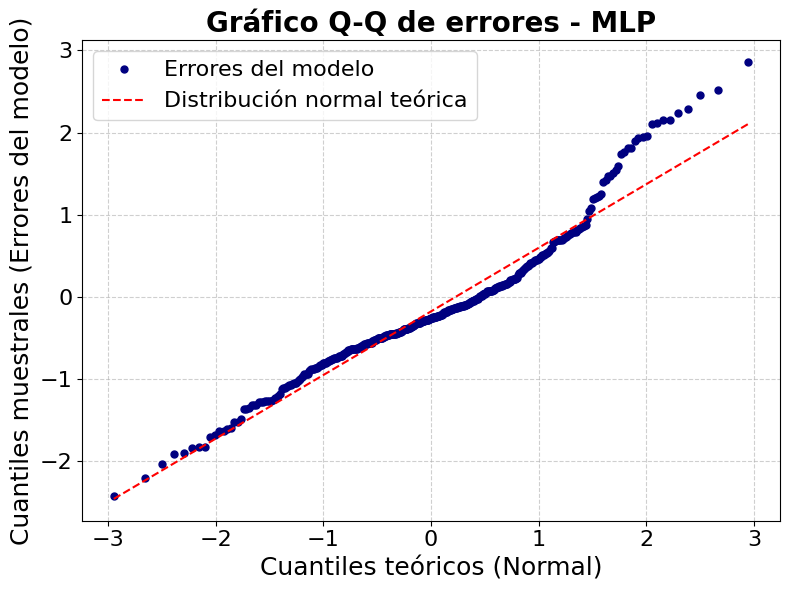

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


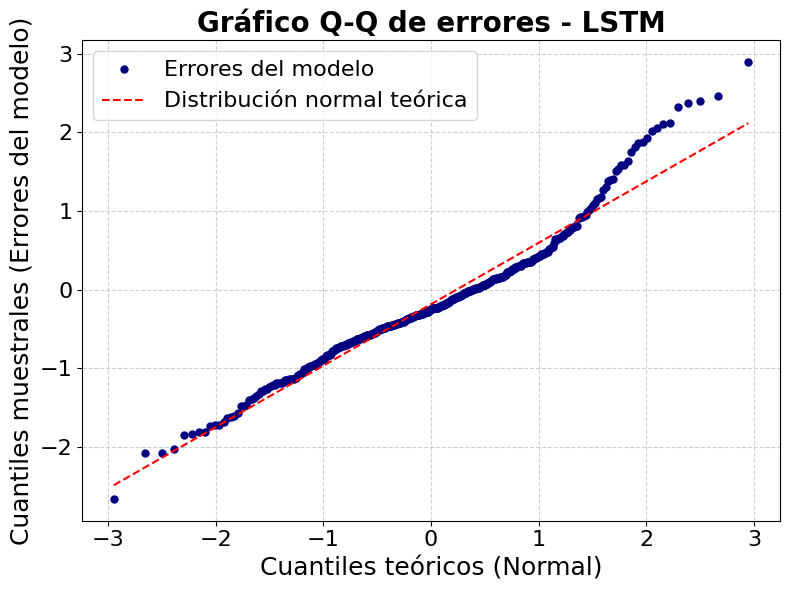

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


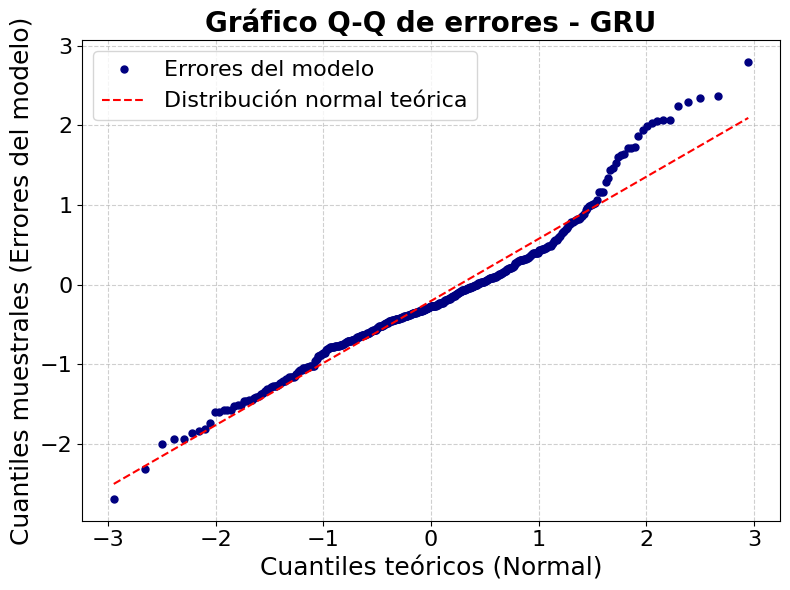

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


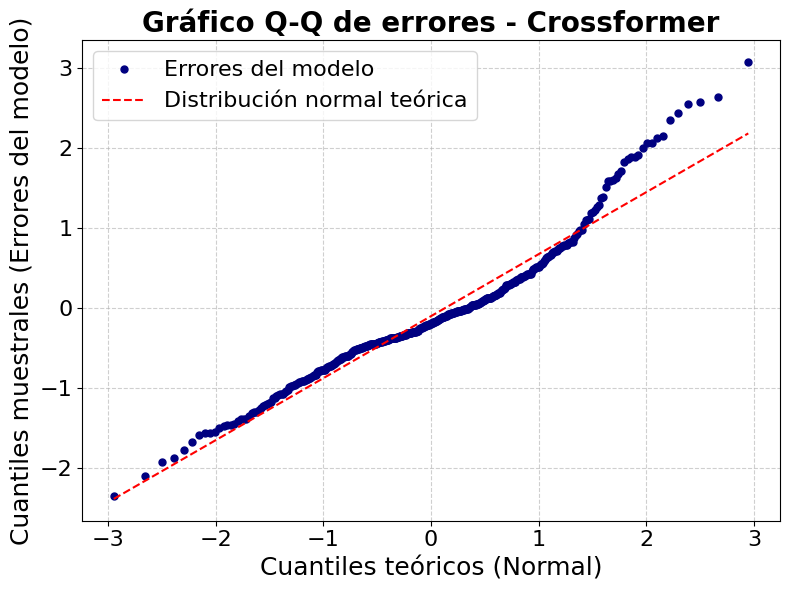

In [19]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


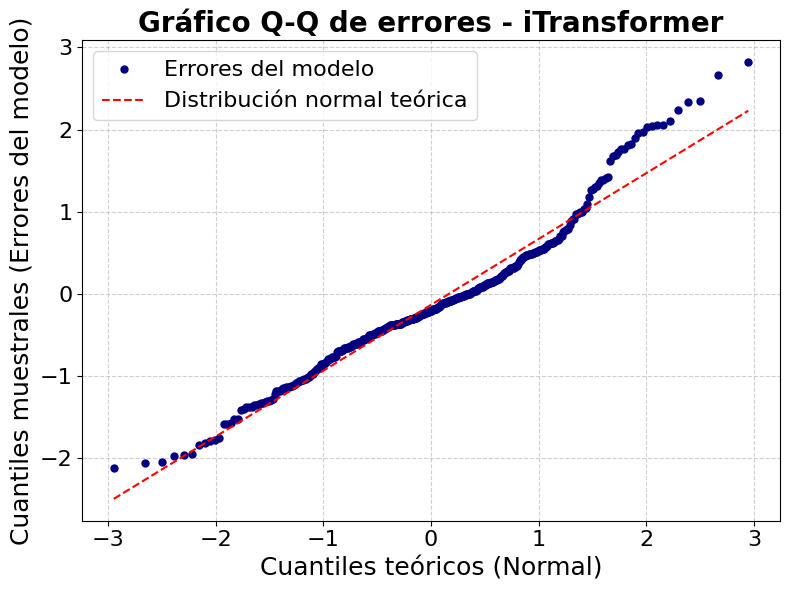

In [20]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


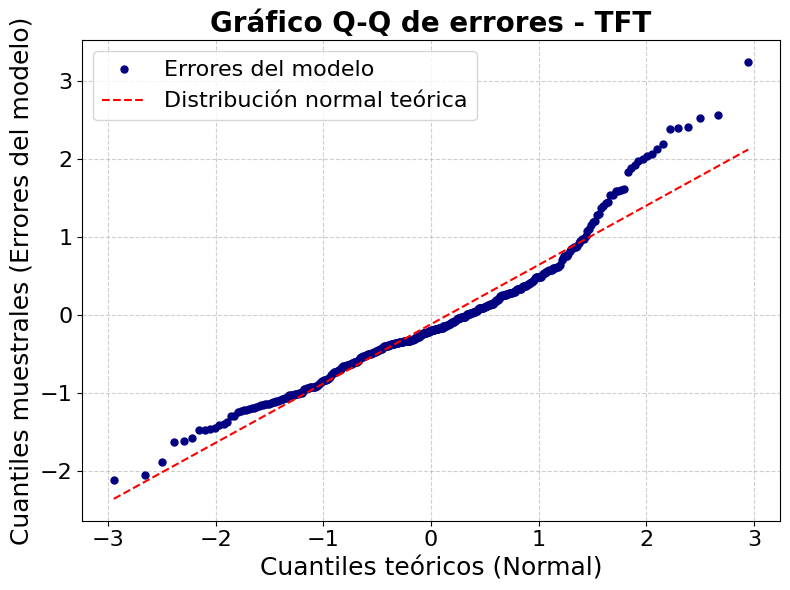

In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
def formatear_mes(x, pos):
    fecha = mdates.num2date(x)
    return meses.get(fecha.month, '')

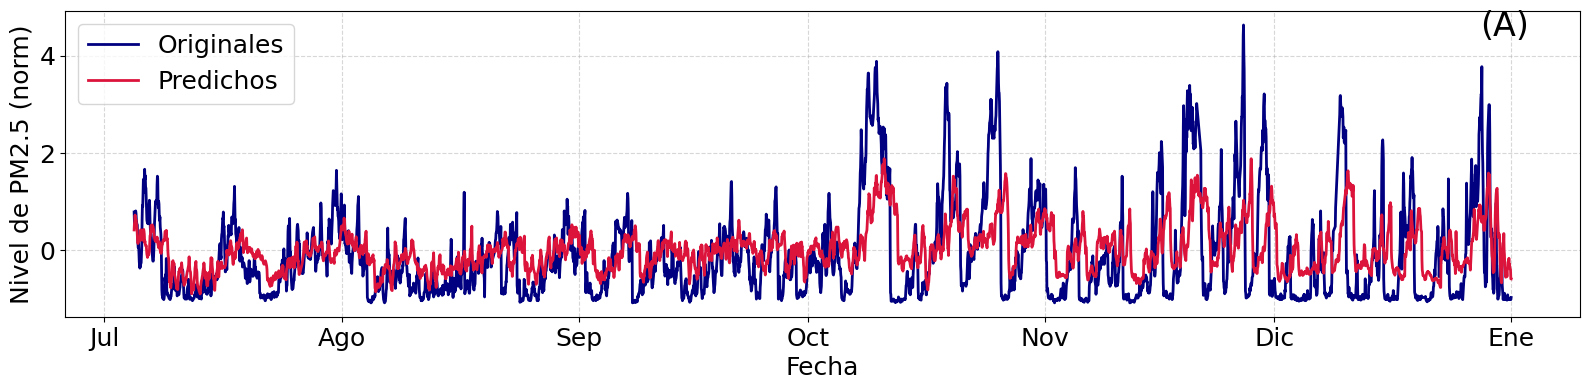

In [23]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosMLP

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


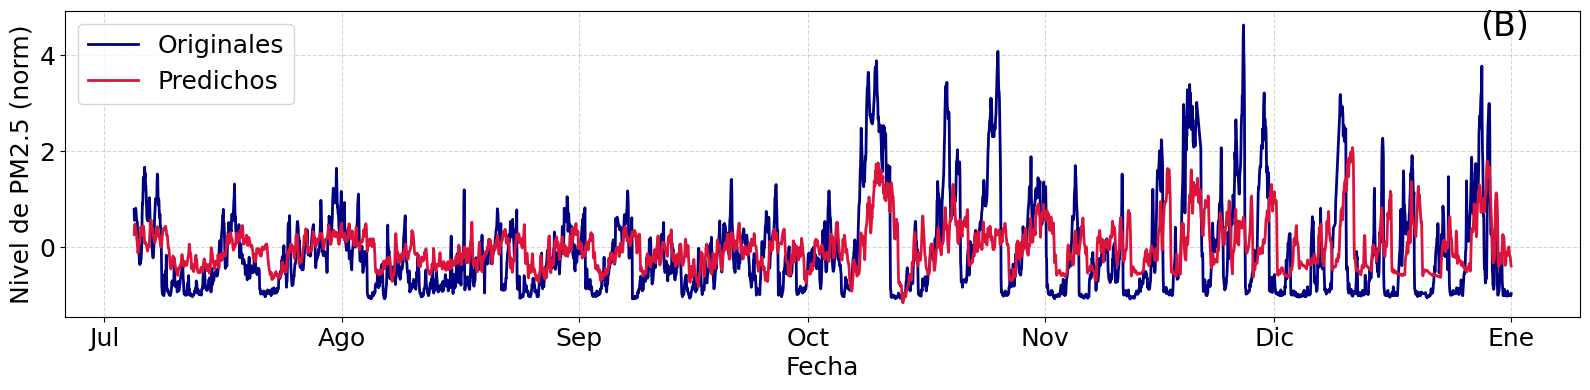

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosLSTM

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


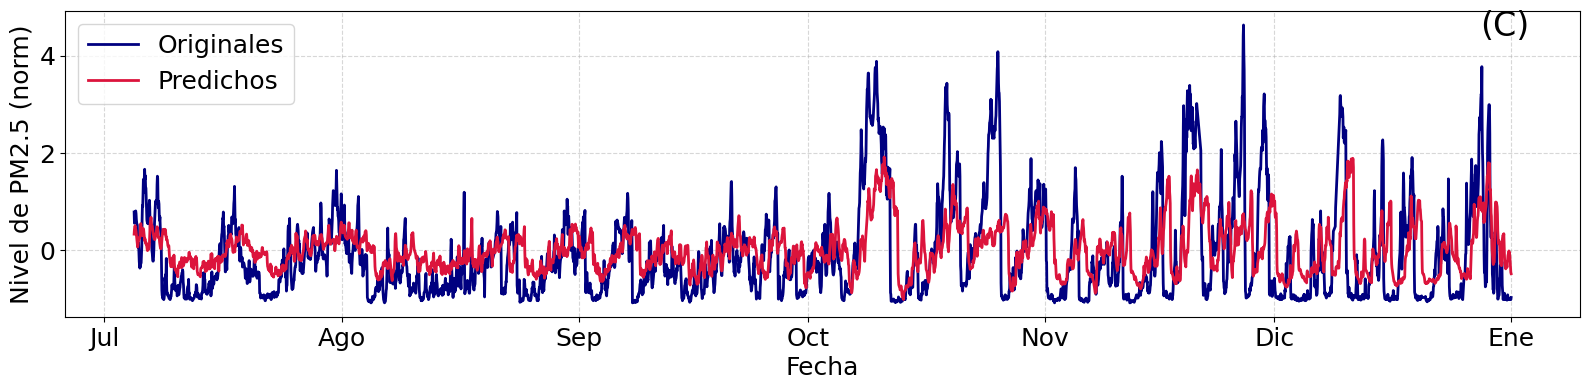

In [25]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosGRU

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


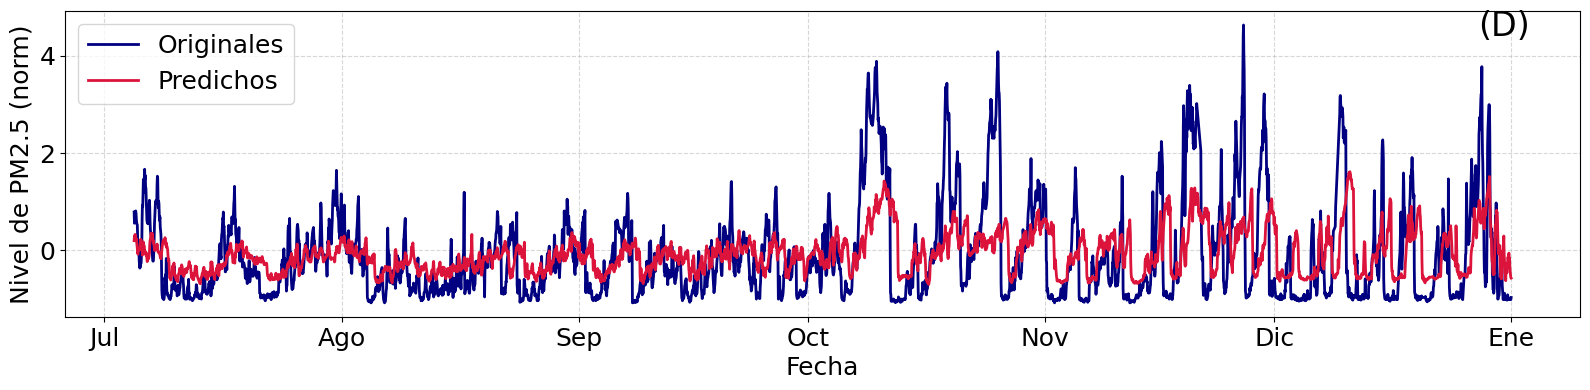

In [26]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosCross

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


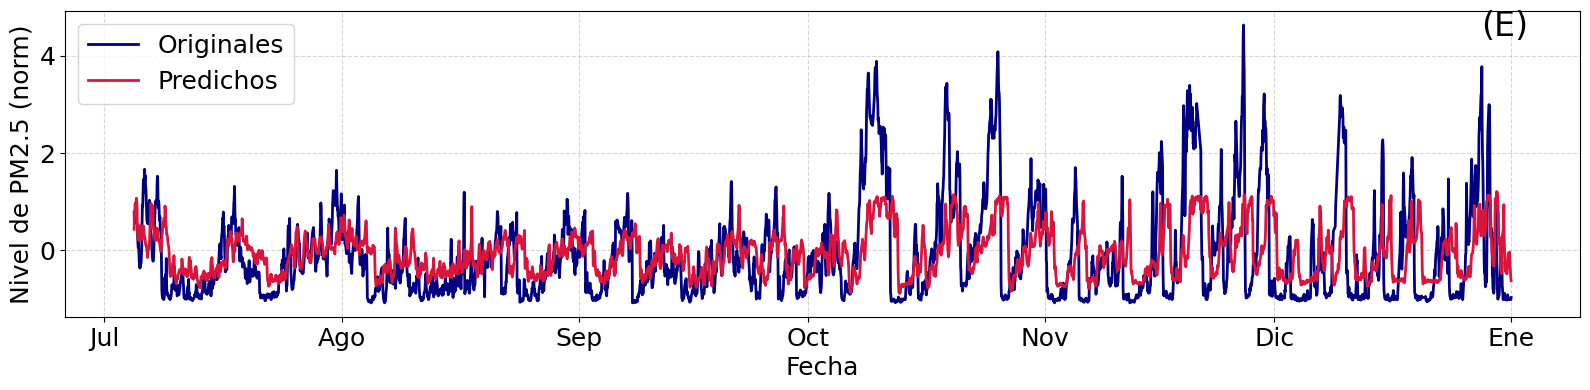

In [27]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosI

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


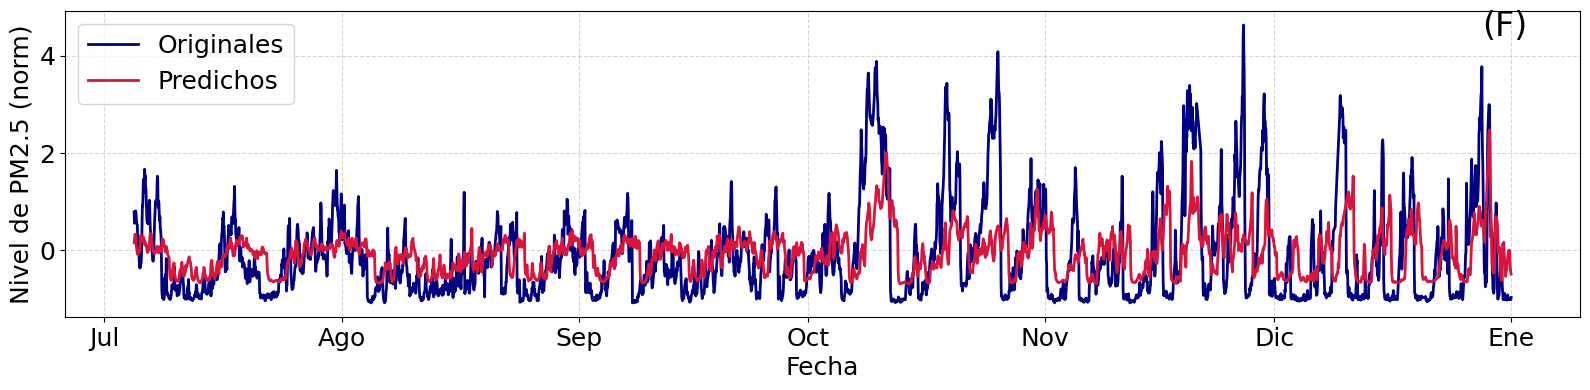

In [28]:
fig, ax = plt.subplots(figsize=(16, 4))

df = datosTFT

ax.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')

ax.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

ax.set_xlabel("Fecha", fontsize=18)
ax.set_ylabel("Nivel de PM2.5 (norm)", fontsize=18)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_mes))

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(True, linestyle='--', alpha=0.5)

plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)


plt.legend(fontsize=18, loc="best")

plt.tight_layout()

plt.show()


# Métricas

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [30]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7788423033730125
RMSE: 0.8825204266038337
MAE: 0.6605102608063076
SMAPE: 1.256833415297051
IA: 0.3920622525838334


In [31]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7780149941818153
RMSE: 0.8820515824949329
MAE: 0.6543847391602926
SMAPE: 1.2304058547064762
IA: 0.39989013476542234


In [32]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7875275213462046
RMSE: 0.8874274738513591
MAE: 0.6616361860114816
SMAPE: 1.2267647110808892
IA: 0.4022595196847025


In [33]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7712612752114039
RMSE: 0.8782148229285383
MAE: 0.642455946820651
SMAPE: 1.2068397143889515
IA: 0.39522969420937903


In [34]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7941170006754352
RMSE: 0.8911324260038096
MAE: 0.656062841552459
SMAPE: 1.1860153919318224
IA: 0.4140832398054164


In [35]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.7640247898718463
RMSE: 0.8740851159194087
MAE: 0.6404985876979036
SMAPE: 1.233924746942396
IA: 0.4055705038616053


# Pruebas de significación

In [36]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [37]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 8.446345681221509e-16
LSTM: 2.160433013493157e-13
GRU: 3.249669157121748e-14
Cross: 6.149352189549262e-11
iTransf: 1.636375077663707e-10
TFT: 4.602493107183376e-11


In [38]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

7.768484412757043e-55


In [39]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.05650,0.84745,0.11299
1,MLP vs GRU,0.00008,0.00116,0.00046
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00002,0.00032,0.00015
4,MLP vs TFT,0.00000,0.00006,0.00003
5,LSTM vs GRU,0.00011,0.00159,0.00053
6,LSTM vs Crossformer,0.00000,0.00000,0.00000
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00000,0.00000,0.00000
